In [1]:
import pandas as pd
import numpy as np
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

In [3]:
iris = pd.read_csv('data/iris.csv')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,se
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.3+ KB


In [5]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


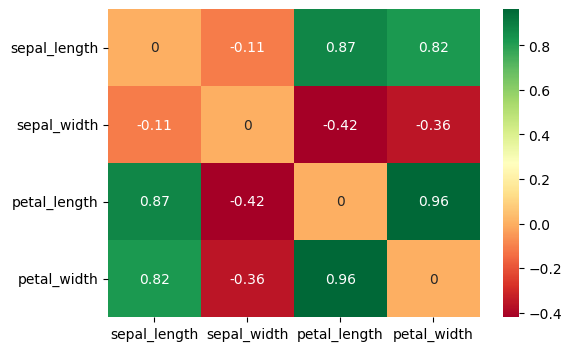

In [6]:
iris_corr = iris.drop('species', axis=1).corr()
for x in range(len(iris.columns)-1):
    iris_corr.iloc[x,x] = 0.0
plt.figure(figsize=(6,4))
sns.heatmap(iris_corr, annot=True, cmap='RdYlGn')
plt.show()

In [7]:
iris_corr.abs().idxmax()

sepal_length    petal_length
sepal_width     petal_length
petal_length     petal_width
petal_width     petal_length
dtype: object

In [8]:
iris_corr.abs().max()

sepal_length    0.871754
sepal_width     0.420516
petal_length    0.962757
petal_width     0.962757
dtype: float64

In [9]:
X = iris.drop('species', axis = 1)
Y = iris['species']

In [10]:
skew_col = X.skew().abs().sort_values(ascending=False)
skew_col = skew_col.loc[skew_col > 0.75]
print(skew_col)
for col in skew_col.index.tolist():
    X[col] = np.log1p(X[col])

Series([], dtype: float64)


In [11]:
X.skew().abs().sort_values(ascending=False)

sepal_width     0.334053
sepal_length    0.314911
petal_length    0.274464
petal_width     0.104997
dtype: float64

In [12]:
ss = StandardScaler()

X_ss = ss.fit_transform(X)

In [13]:
rs = 42

In [14]:
scores = pd.DataFrame(columns=['Model','Clusters','Silhoutte Score'])

In [15]:
def display_km_cluster(X,km=[],num_clu=0):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20
    if num_clu == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clu):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

In [16]:
def plot_gmm(gmm, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X_ss).predict(X_ss)
    if label:
        ax.scatter(X_ss[:, 0], X_ss[:, 1], c=labels, s=20, cmap='viridis', zorder=2)
    else:
        ax.scatter(X_ss[:, 0], X_ss[:, 1], s=20, zorder=2)
    ax.axis('equal')

In [17]:
def display_agg_cluster(X,agg=[]):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20
    labels = agg.fit_predict(X)
    plt.scatter(X[:,0],X[:,1],c = labels, alpha = alpha, s = s)

In [18]:
def display_dbs_cluster(X,dbs=[]):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20
    labels = dbs.labels_
    plt.scatter(X[:,0],X[:,1],c = labels, alpha = alpha, s = s)

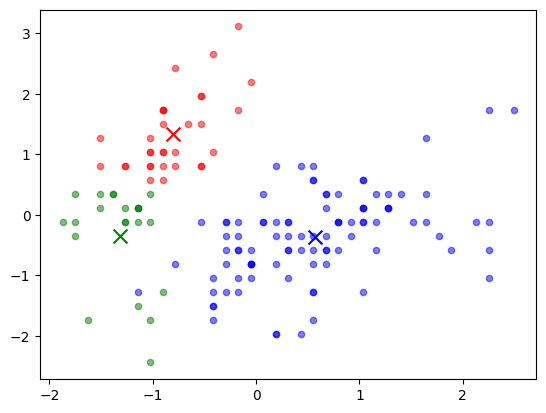

In [19]:
km3 = KMeans(n_clusters = 3, random_state = rs)
km3.fit(X_ss)

display_km_cluster(X_ss, km3, num_clu = 3)
sil_score = silhouette_score(X_ss, km3.labels_)
scores.loc[len(scores)] = ['K-means', 3, sil_score] 

In [20]:
km_list = list()
for clu in range(2,7):
    km = KMeans(n_clusters = clu, random_state = rs)
    km = km.fit(X_ss)
    
    km_list.append(pd.Series({'clusters': clu, 
                              'inertia': km.inertia_,
                              'model': km}))

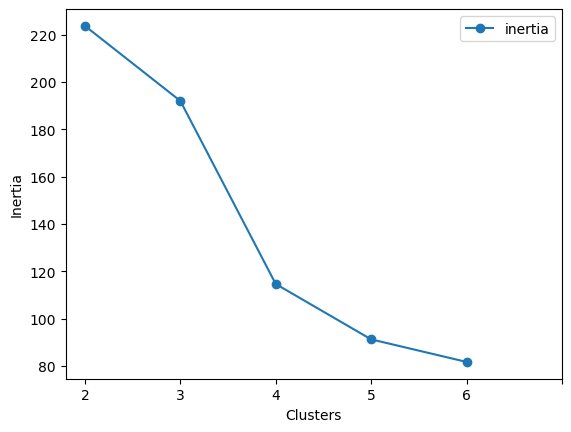

In [21]:
plot_data = (pd.concat(km_list, axis=1)
             .T
             [['clusters','inertia']]
             .set_index('clusters'))

ax = plot_data.plot(marker='o',ls='-')
ax.set_xticks(range(0,6))
ax.set(xlabel='Clusters', ylabel='Inertia');

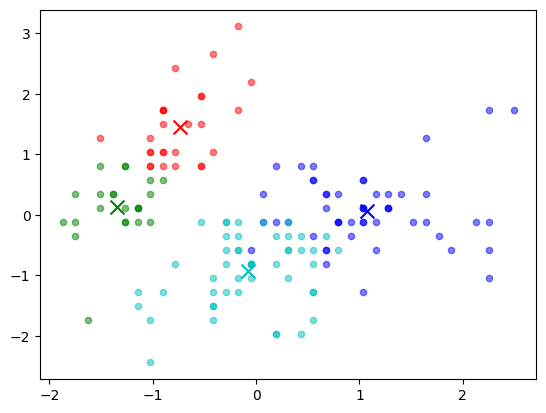

In [22]:
km4 = KMeans(n_clusters = 4, random_state = rs)
km4.fit(X_ss)
display_km_cluster(X_ss, km4, num_clu = 4)
sil_score = silhouette_score(X_ss, km4.labels_)
scores.loc[len(scores)] = ['K-means', 4, sil_score] 

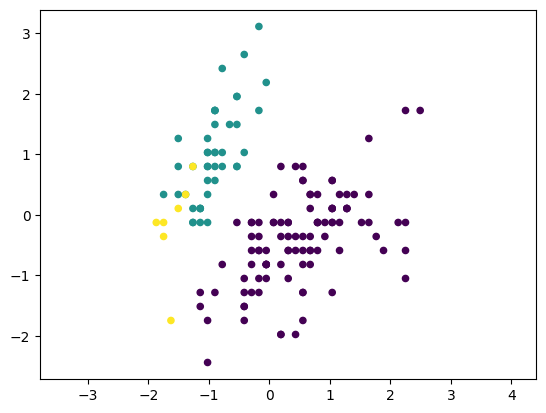

In [23]:
gmm3 = GaussianMixture(n_components = 3, random_state = rs)
gmm3.fit(X_ss)
lab = gmm3.predict(X_ss)

sil_score = silhouette_score(X_ss, lab)
scores.loc[len(scores)] = ['Gaussian Mixture Model', 3, sil_score]

plot_gmm(gmm3)

Best silhouette score =  0.580184463257396
Best covariance type =  full
Best component number =  2


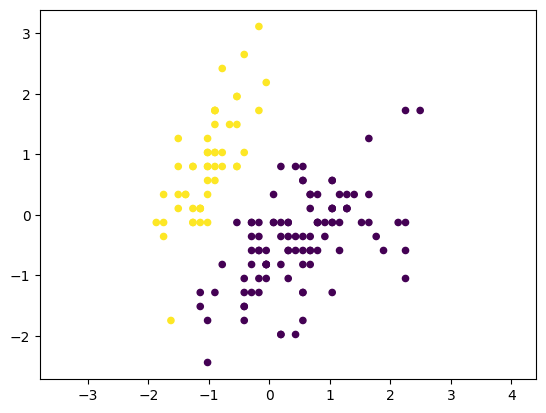

In [24]:
sil_max = 0;
for comp in range(2,7):
    for cotype in ['full','tied']:
        gmm = GaussianMixture(n_components = comp, covariance_type = cotype, random_state = rs)
        gmm = gmm.fit(X_ss)
        lab = gmm.predict(X_ss)
        sil_score = silhouette_score(X_ss, lab)
        if (sil_max < sil_score):
            sil_max = sil_score
            gmm_best = gmm
            comp_best = comp
            type_best = cotype
    
scores.loc[len(scores)] = ['Gaussian Mixture Model', comp_best, sil_max]
print("Best silhouette score = ", sil_max)
print("Best covariance type = ", type_best)
print("Best component number = ", comp_best)
plot_gmm(gmm_best)

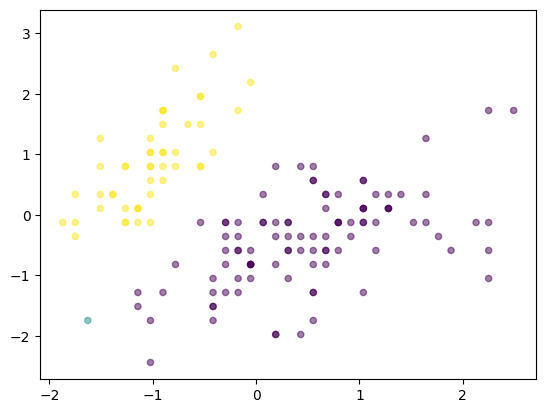

In [25]:
agg3 = AgglomerativeClustering(n_clusters=3, linkage='single')
agg3.fit(X_ss)
lab = agg3.fit_predict(X_ss)

sil_score = silhouette_score(X_ss, lab)
scores.loc[len(scores)] = ['Agglomerative Clustering', 3, sil_score]

display_agg_cluster(X_ss, agg3)

Best silhouette score =  0.580184463257396
Best linkage =  single
Best cluster number =  2


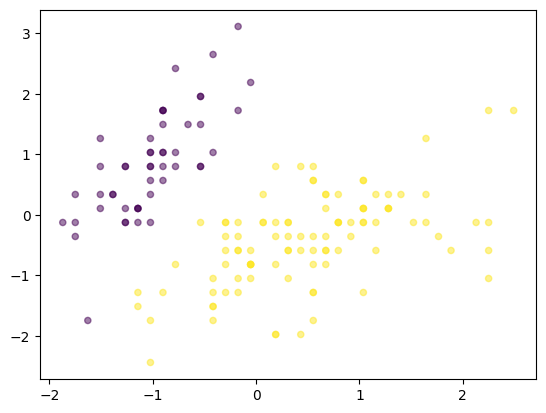

In [26]:
sil_max = 0;
for clu in range(2,7):
    for link in ['single','complete','average','ward']:
        agg = AgglomerativeClustering(n_clusters = clu, linkage = link)
        agg = agg.fit(X_ss)
        lab = agg.fit_predict(X_ss)
        sil_score = silhouette_score(X_ss, lab)
        if (sil_max < sil_score):
            sil_max = sil_score
            agg_best = agg
            clu_best = clu
            link_best = link
    
scores.loc[len(scores)] = ['Agglomerative Clustering', clu_best, sil_max]
print("Best silhouette score = ", sil_max)
print("Best linkage = ", link_best)
print("Best cluster number = ", clu_best)
display_agg_cluster(X_ss, agg_best)

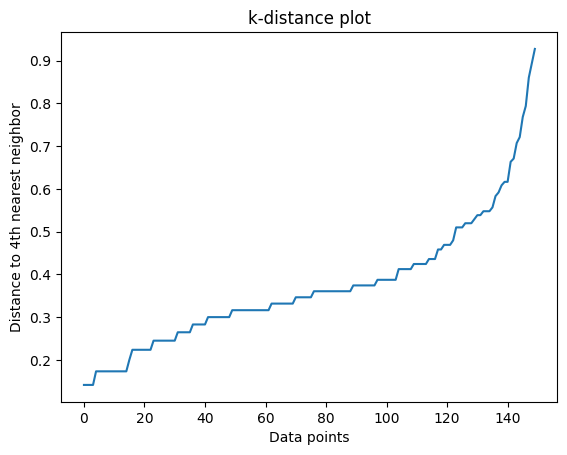

In [27]:
from sklearn.neighbors import NearestNeighbors

neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

# Sort the distances to the 4th nearest neighbor
sorted_distances = np.sort(distances[:, -1], axis=0)

# Plot the sorted distances
plt.plot(sorted_distances)
plt.xlabel('Data points')
plt.ylabel('Distance to 4th nearest neighbor')
plt.title('k-distance plot')
plt.show()

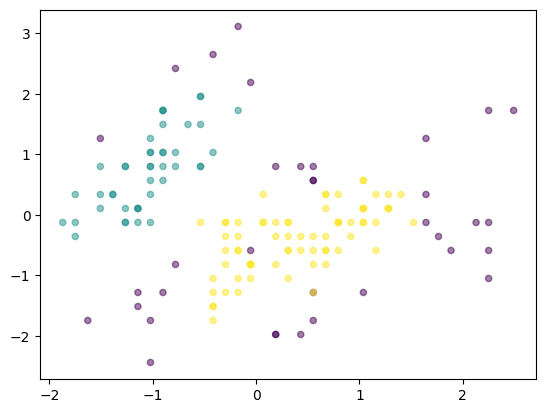

In [28]:
dbs1 = DBSCAN(eps = 0.5, min_samples = 5)
dbs1.fit(X_ss)
lab = dbs1.labels_

sil_score = silhouette_score(X_ss, lab)
scores.loc[len(scores)] = ['DBSCAN', len(set(lab)), sil_score]

display_dbs_cluster(X_ss, dbs1)

Best silhouette score =  0.5215635176967445
Best neighbourhood radius =  0.8
Best cluster number =  3


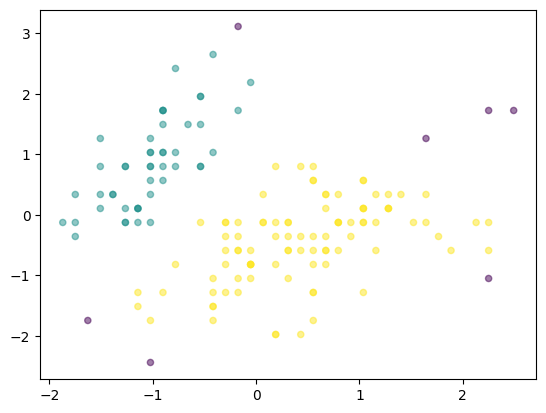

In [29]:
sil_max = 0;
for ep in [0.4, 0.5, 0.6, 0.7, 0.8]:
    for samp in range(5,10):
        dbs = DBSCAN(eps = ep, min_samples = samp)
        dbs.fit(X_ss)
        lab = dbs.labels_
        sil_score = silhouette_score(X_ss, lab)
        if (sil_max < sil_score):
            sil_max = sil_score
            dbs_best = dbs
            eps_best = ep
            clu_best = len(set(lab))
            
    
scores.loc[len(scores)] = ['DBSCAN', clu_best, sil_max]
print("Best silhouette score = ", sil_max)
print("Best neighbourhood radius = ", eps_best)
print("Best cluster number = ", clu_best)
display_dbs_cluster(X_ss, dbs_best)

In [30]:
scores

,Model,Clusters,Silhoutte Score
0,K-means,3,0.478724
1,K-means,4,0.387247
2,Gaussian Mixture Model,3,0.409184
3,Gaussian Mixture Model,2,0.580184
4,Agglomerative Clustering,3,0.502877
5,Agglomerative Clustering,2,0.580184
6,DBSCAN,3,0.349198
7,DBSCAN,3,0.521564
